In [39]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np

def load_gauge_and_discharge(
    gauge_shp_dir,
    gauge_shp_name,
    discharge_folder,
    gauge_index=0,
    target_crs="EPSG:32618",
    default_crs="EPSG:4326",
):
    """
    Unified loader that:
      1) Loads upstream gauge shapefile (NO geometry use downstream)
      2) Fixes missing CRS and projects safely (optional)
      3) Selects a gauge by row index
      4) Extracts USGS ID from gauge name
      5) Loads corresponding discharge CSV
      6) Returns everything needed for hydrograph modeling

    Returns
    -------
    gauges : GeoDataFrame
        Loaded gauge table (geometry preserved but not required)
    gauge_label : str
        Name/ID used for the selected gauge
    usgs_id : str
        Parsed USGS ID
    df : DataFrame
        Datetime-indexed discharge dataframe
    Q : ndarray
        Discharge array [nt]
    nt : int
        Number of time steps
    t_days : ndarray
        Time vector in days [nt]
    """


    # -------------------------------------------------
    # Load gauges
    # -------------------------------------------------
    shp_path = os.path.join(gauge_shp_dir, gauge_shp_name)
    if not os.path.exists(shp_path):
        raise FileNotFoundError(f"Gauge shapefile not found: {shp_path}")

    gauges = gpd.read_file(shp_path)

    # Fix missing CRS
    if gauges.crs is None:
        gauges = gauges.set_crs(default_crs)

    # Project safely (geometry not actually used later)
    if str(gauges.crs) != str(target_crs):
        try:
            gauges = gauges.to_crs(target_crs)
        except Exception:
            pass

    if gauge_index < 0 or gauge_index >= len(gauges):
        raise IndexError(
            f"gauge_index={gauge_index} out of range (0..{len(gauges)-1})"
        )

    # -------------------------------------------------
    # Pick gauge label
    # -------------------------------------------------
    row = gauges.iloc[gauge_index]

    if "Name" in gauges.columns and pd.notna(row.get("Name", None)):
        gauge_label = str(row["Name"])
    elif "ID" in gauges.columns and pd.notna(row.get("ID", None)):
        gauge_label = str(row["ID"])
    else:
        gauge_label = "UNKNOWN"

    # -------------------------------------------------
    # Extract USGS ID
    # -------------------------------------------------
    if "_" in gauge_label:
        usgs_id = gauge_label.split("_")[-1]
    else:
        usgs_id = gauge_label

    # -------------------------------------------------
    # Load discharge CSV
    # -------------------------------------------------
    csv_path = os.path.join(discharge_folder, f"{usgs_id}.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Discharge file not found: {csv_path}")

    df = pd.read_csv(csv_path, header=0, names=["datetime", "discharge_m3s"])
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime").sort_index()
    Q = df
    # Q = df["discharge_m3s"].to_numpy(dtype=float)
    nt = len(Q)

    total_days = (df.index[-1] - df.index[0]).total_seconds() / (24 * 3600)
    t_days = np.linspace(0.0, total_days, nt)

    return gauges, gauge_label, usgs_id, df, Q, nt, t_days


In [ ]:
# ============================================================
# UPDATED: generator takes a discharge DataFrame (datetime index)
# and returns synthetics as DataFrames with the SAME datetime index.
# ============================================================

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter


def generate_synthetic_hydrographs_from_real(
    Q_df,                  # pandas DataFrame or Series with datetime index
    value_col="discharge_m3s",
    n=500,
    seed=0,
    enforce_peak_range=True,

    # peak range rule (relative to real max)
    peak_factor_range=(0.70, 1.20),   # A=0.70*Qmax, B=1.20*Qmax

    # template smoothing
    smooth_real=True,
    real_smooth_window=31,
    real_smooth_poly=3,

    # time warp
    warp_a_range=(0.75, 1.35),
    t_split_range=(0.20, 0.40),

    # main shape edits
    peak_scale_range=(0.90, 1.15),
    peak_sharp_range=(0.90, 1.25),
    recession_k_range=(0.85, 1.20),

    # tail control
    floor_factor_range=(0.90, 1.80),
    floor_strength=4.0,
    end_offset_range=(-0.02, 0.10),
    end_offset_strength=4.0,

    # final smoothing
    smooth_syn_window=23,
    smooth_syn_poly=3,

    # double peak controls
    p_double=0.7,
    dt2_range=(0.035, 0.10),
    dip_dt_range=(0.015, 0.045),
    dip_depth_range=(0.10, 0.25),
    peak2_amp_range=(0.15, 0.35),
    width_dip_range=(0.010, 0.030),
    width_peak2_range=(0.015, 0.045),
):
    """
    Input
    -----
    Q_df : pandas.DataFrame or pandas.Series
        Must have datetime index. If DataFrame, uses `value_col`.

    Returns
    -------
    Q_syn_df : pandas.DataFrame
        Synthetic discharge with SAME datetime index.
        Columns: syn_000, syn_001, ..., syn_{n-1}
    Q_norm_df : pandas.DataFrame
        Same synthetics normalized to [0,1] using (Qmin,Qmax) from the *smoothed real*.
        Same datetime index and column names.
    meta : dict
        Contains: Qmin, Qmax, base, peak_range_m3s, seed, n
    """

    rng = np.random.default_rng(seed)

    # ---- coerce input to Series with datetime index
    if isinstance(Q_df, pd.Series):
        q_series = Q_df.copy()
    elif isinstance(Q_df, pd.DataFrame):
        if value_col not in Q_df.columns:
            raise ValueError(f"value_col='{value_col}' not found in Q_df.columns={list(Q_df.columns)}")
        q_series = Q_df[value_col].copy()
    else:
        raise TypeError("Q_df must be a pandas DataFrame or Series with a datetime index.")

    if not isinstance(q_series.index, pd.DatetimeIndex):
        raise TypeError("Q_df must have a DatetimeIndex.")

    # ---- numeric array + fill missing
    Q = q_series.to_numpy(dtype=float)
    if not np.all(np.isfinite(Q)):
        idx = np.arange(len(Q))
        good = np.isfinite(Q)
        Q = np.interp(idx, idx[good], Q[good])

    # ---- smooth the real series for template
    Q_sm = Q.copy()
    if smooth_real and len(Q_sm) >= 7:
        w = min(real_smooth_window, len(Q_sm) - (1 - len(Q_sm) % 2))
        if w < 7:
            w = 7 if len(Q_sm) >= 7 else (len(Q_sm) // 2) * 2 + 1
        if w % 2 == 0:
            w += 1
        Q_sm = savgol_filter(Q_sm, w, min(real_smooth_poly, w - 1))

    nt = len(Q_sm)
    t = np.linspace(0.0, 1.0, nt)

    Qmin = float(np.min(Q_sm))
    Qmax = float(np.max(Q_sm))

    q0 = (Q_sm - Qmin) / (Qmax - Qmin + 1e-12)
    q_start = float(q0[0])

    # IMPORTANT: baseflow anchor should match ORIGINAL series start, not smoothed
    base = float(Q[0])

    # peak range computed from REAL max (original, not smoothed)
    real_peak = float(np.max(Q))
    A = peak_factor_range[0] * real_peak
    B = peak_factor_range[1] * real_peak
    peak_range_m3s = (A, B)

    # ---- internal helpers
    def time_warp(t, a, t_split):
        s_split = np.clip(a * t_split, 1e-6, 1 - 1e-6)
        slope2 = (1.0 - s_split) / (1.0 - t_split)
        s = np.empty_like(t)
        m1 = t <= t_split
        s[m1] = a * t[m1]
        s[~m1] = s_split + slope2 * (t[~m1] - t_split)
        return np.clip(s, 0.0, 1.0)

    def gauss(t, c, w, a):
        return a * np.exp(-0.5 * ((t - c) / (w + 1e-12))**2)

    def smooth_syn(y):
        if nt < 7:
            return y
        w = min(smooth_syn_window, nt - (1 - nt % 2))
        if w < 7:
            w = 7 if nt >= 7 else (nt // 2) * 2 + 1
        if w % 2 == 0:
            w += 1
        return savgol_filter(y, w, min(smooth_syn_poly, w - 1))

    # -------------------------------------------------
    # 1) generate normalized synthetics
    # -------------------------------------------------
    syn_norm = np.zeros((n, nt), dtype=float)

    for i in range(n):
        a = rng.uniform(*warp_a_range)
        t_split = rng.uniform(*t_split_range)
        s = time_warp(t, a, t_split)
        q = np.interp(s, t, q0)

        q = np.clip(rng.uniform(*peak_scale_range) * q, 0.0, 2.0)
        q = np.clip(q, 0.0, 1.0) ** (1.0 / rng.uniform(*peak_sharp_range))

        j1 = int(np.argmax(q))
        t1 = t[j1]

        if rng.random() < p_double:
            t_dip = np.clip(t1 + rng.uniform(*dip_dt_range), 0.05, 0.95)
            t2 = np.clip(t1 + rng.uniform(*dt2_range), 0.05, 0.97)
            if t2 <= t_dip + 0.01:
                t2 = np.clip(t_dip + 0.02, 0.05, 0.97)

            q -= gauss(t, t_dip, rng.uniform(*width_dip_range), rng.uniform(*dip_depth_range))
            q += gauss(t, t2,    rng.uniform(*width_peak2_range), rng.uniform(*peak2_amp_range))

        q = np.clip(q, 0.0, 1.0)

        j_peak = int(np.argmax(q))
        k_rec = rng.uniform(*recession_k_range)
        if j_peak < nt - 2:
            tt = np.linspace(0.0, 1.0, nt - j_peak)
            q[j_peak:] *= (1.0 - tt) ** k_rec

        q[0] = q_start

        q_floor = rng.uniform(*floor_factor_range) * q_start
        w_floor = (1.0 - q) ** floor_strength
        w_floor[:j_peak] = 0.0
        q += w_floor * np.maximum(0.0, q_floor - q)

        w_end = (1.0 - q) ** end_offset_strength
        w_end[:j_peak] = 0.0
        q += w_end * rng.uniform(*end_offset_range)

        q = smooth_syn(np.clip(q, 0.0, 1.0))
        q[0] = q_start

        syn_norm[i] = np.clip(q, 0.0, 1.0)

    # -------------------------------------------------
    # 2) normalized -> discharge
    # -------------------------------------------------
    syn_Q = Qmin + syn_norm * (Qmax - Qmin)
    syn_Q[:, 0] = base

    # -------------------------------------------------
    # 3) enforce peak range in discharge units (optional)
    # -------------------------------------------------
    if enforce_peak_range:
        if B <= A:
            raise ValueError(f"Invalid peak range computed: {peak_range_m3s}")
        if B <= base:
            raise ValueError(f"Peak upper bound B={B:.3f} must be > baseflow Q[0]={base:.3f}")

        peaks_now = syn_Q.max(axis=1)
        target_peaks = rng.uniform(A, B, size=n)

        scale = (target_peaks - base) / (peaks_now - base + 1e-12)
        scale = np.clip(scale, 0.1, 10.0)

        syn_Q = base + (syn_Q - base) * scale[:, None]
        syn_Q[:, 0] = base

        # keep normalized consistent with final syn_Q
        syn_norm = (syn_Q - Qmin) / (Qmax - Qmin + 1e-12)
        syn_norm = np.clip(syn_norm, 0.0, 1.0)

    # -------------------------------------------------
    # 4) pack as DataFrames with SAME datetime index
    # -------------------------------------------------
    idx = q_series.index
    cols = [f"syn_{i:03d}" for i in range(n)]

    Q_syn_df = pd.DataFrame(syn_Q.T, index=idx, columns=cols)
    Q_norm_df = pd.DataFrame(syn_norm.T, index=idx, columns=cols)

    meta = dict(
        Qmin=Qmin,
        Qmax=Qmax,
        base=base,
        peak_range_m3s=peak_range_m3s,
        seed=seed,
        n=n,
        value_col=value_col,
    )

    return Q_syn_df, Q_norm_df, meta


Bc1_8791413 8791413 265
Peak range used: (1061.9839762628078, 1820.5439593076705)
Synthetic shape: (265, 500)


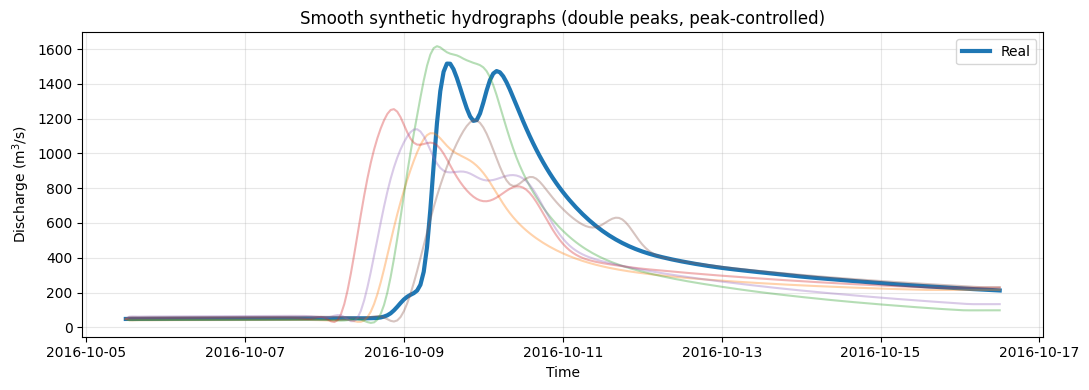

In [74]:
import numpy as np
import matplotlib.pyplot as plt

gauges, label, usgs_id, df, Q_df, nt, t_days = load_gauge_and_discharge(
    gauge_shp_dir="/storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/UpstreamLocations",
    gauge_shp_name="UpstreamBoundry_locations.shp",
    discharge_folder="/storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/discharge_1main&7tributaries",
    gauge_index=0,
)

print(label, usgs_id, nt)

N_SYN = 500
SEED  = 0

# Q_df is a DataFrame with datetime index and column discharge_m3s
Q_syn_df, Q_norm_df, meta = generate_synthetic_hydrographs_from_real(
    Q_df,
    value_col="discharge_m3s",
    n=N_SYN,
    seed=SEED,
    enforce_peak_range=True,
    peak_factor_range=(0.70, 1.20),   # uses 0.7*real_peak .. 1.2*real_peak
        # final smoothing
    smooth_syn_window=25,
    smooth_syn_poly=10,

    # double peak controls
    p_double=0.7,
    dt2_range=(0.035, 0.2),

    t_split_range=(0.1, 1.0),
        # tail control
    floor_factor_range=(0.2, 1.0),
    floor_strength=5.0,
    end_offset_range=(-0.0, 0.2),
    end_offset_strength=2.0

)

print("Peak range used:", meta["peak_range_m3s"])
print("Synthetic shape:", Q_syn_df.shape)  # [nt, N_SYN]

# ------------------------------------------------------------
# Plot (use SAME time index)
# ------------------------------------------------------------
plt.figure(figsize=(11, 4))
plt.plot(Q_df.index, Q_df["discharge_m3s"].values, lw=3, label="Real")

n_plot = min(5, N_SYN)
for k in range(n_plot):
    plt.plot(Q_syn_df.index, Q_syn_df[f"syn_{k:03d}"].values, alpha=0.35)

plt.xlabel("Time")
plt.ylabel("Discharge (m$^3$/s)")
plt.title("Smooth synthetic hydrographs (double peaks, peak-controlled)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
